# 01_EDA — Исследовательский анализ данных

**Цель ноутбука:**  
Познакомиться с сырыми данными об инцидентах информационной безопасности, понять структуру и качество данных,
выявить основные закономерности и подготовить датасет к этапу построения признаков.

**Входные файлы:**
- `data/raw/incidents_2000.csv` — таблица инцидентов (события ИБ)
- `data/raw/thrlist.csv` — справочник угроз (БнД УБИ ФСТЭК)

**Выходные файлы:**
- `data/interim/df_clean.parquet` — очищенный датафрейм для следующего этапа


## 1. Установка зависимостей

In [1]:
# Устанавливаем необходимые библиотеки, если они не установлены
# В Colab catboost обычно уже предустановлен
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Импорт библиотек

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# Визуализация
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Стили графиков
sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print("Библиотеки загружены успешно")

Библиотеки загружены успешно


## 3. Загрузка данных

Загружаем два источника:
- **incidents** — журнал инцидентов ИБ: каждая строка = один зафиксированный инцидент
- **thrlist** — справочник угроз ФСТЭК: содержит описание, статус, тип нарушителя и другие атрибуты угрозы


In [3]:
# Пути к файлам (адаптируйте при необходимости)
base_path = Path('..')  # корень проекта

inc_path = (base_path / 'data/raw/incidents_2000.csv').resolve()
thr_path = (base_path / 'data/raw/thrlist.csv').resolve()

# Загрузка данных
inc = pd.read_csv(inc_path)
thr = pd.read_csv(thr_path, header=1)  # у thrlist заголовок на 2-й строке

print(f"incidents shape: {inc.shape}")
print(f"thrlist  shape: {thr.shape}")

incidents shape: (2000, 8)
thrlist  shape: (227, 12)


In [4]:
# Быстрый взгляд на инциденты
print("=== incidents: первые строки ===")
display(inc.head(3))
print("\n=== Типы столбцов ===")
print(inc.dtypes)

=== incidents: первые строки ===


,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28



=== Типы столбцов ===
Тип предприятия                  object
Код предприятия                   int64
Количество хостов                 int64
Код реализованной угрозы          int64
Успех                             int64
Регион размещения предприятия    object
Дата инцидента                   object
Региональное время               object
dtype: object


In [5]:
# Быстрый взгляд на справочник угроз
print("=== thrlist: первые строки ===")
display(thr.head(3))
print("\n=== Столбцы thrlist ===")
print(thr.columns.tolist())

=== thrlist: первые строки ===


,Идентификатор УБИ,Наименование УБИ,Описание,Источник угрозы (характеристика и потенциал нарушителя),Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,Статус угрозы,Замечания
0,1,Угроза автоматического распространения вредоно...,Угроза заключается в возможности внедрения и з...,Внешний нарушитель со средним потенциалом; Вну...,Ресурсные центры грид-системы,1,1,1,20.03.2015,08.02.2019,Опубликована,NaN
1,2,"Угроза агрегирования данных, передаваемых в гр...",Угроза заключается в возможности раскрытия нар...,Внешний нарушитель со средним потенциалом,Сетевой трафик,1,0,0,20.03.2015,08.02.2019,Опубликована,NaN
2,3,Угроза использования слабостей криптографическ...,Угроза заключается в возможности выявления сла...,Внешний нарушитель со средним потенциалом; Вну...,"Метаданные, системное программное обеспечение",1,1,0,20.03.2015,29.11.2020,Опубликована,NaN



=== Столбцы thrlist ===
['Идентификатор УБИ', 'Наименование УБИ', 'Описание', 'Источник угрозы (характеристика и потенциал нарушителя)', 'Объект воздействия', 'Нарушение конфиденциальности', 'Нарушение целостности', 'Нарушение доступности', 'Дата включения угрозы в БнД УБИ', 'Дата последнего изменения данных', 'Статус угрозы', 'Замечания']


## 4. Объединение таблиц

Соединяем инциденты со справочником угроз по полю «Код реализованной угрозы» = «Идентификатор УБИ».
Используем LEFT JOIN, чтобы не терять инциденты с нераспознанным кодом угрозы.


In [6]:
df = inc.merge(
    thr,
    how='left',
    left_on='Код реализованной угрозы',
    right_on='Идентификатор УБИ'
)

print(f"Размер объединённой таблицы: {df.shape}")
print(f"Строк с незнакомым кодом угрозы: {df['Идентификатор УБИ'].isna().sum()}")
display(df.head(3))

Размер объединённой таблицы: (2000, 20)
Строк с незнакомым кодом угрозы: 0


,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время,Идентификатор УБИ,Наименование УБИ,Описание,Источник угрозы (характеристика и потенциал нарушителя),Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,Статус угрозы,Замечания
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47,190,Угроза внедрения вредоносного кода за счет пос...,Угроза заключается в возможности осуществления...,Внешний нарушитель со средним потенциалом,Сетевое программное обеспечение,1,1,1,21.10.2016,08.02.2019,Опубликована,NaN
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13,152,Угроза удаления аутентификационной информации,Угроза заключается в возможности отказа легити...,Внешний нарушитель с низким потенциалом; Внутр...,"Системное программное обеспечение, микропрогра...",1,1,1,20.03.2015,11.02.2019,Опубликована,NaN
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28,7,Угроза воздействия на программы с высокими при...,Угроза заключается в возможности повышения нар...,Внешний нарушитель со средним потенциалом; Вну...,"Информационная система, виртуальная машина, се...",1,1,0,20.03.2015,08.02.2019,Опубликована,NaN


## 5. Базовая статистика

Изучаем общую картину: типы, пропуски, уникальные значения.


In [7]:
# Информация о столбцах
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Тип предприятия                                          2000 non-null   object
 1   Код предприятия                                          2000 non-null   int64 
 2   Количество хостов                                        2000 non-null   int64 
 3   Код реализованной угрозы                                 2000 non-null   int64 
 4   Успех                                                    2000 non-null   int64 
 5   Регион размещения предприятия                            2000 non-null   object
 6   Дата инцидента                                           2000 non-null   object
 7   Региональное время                                       2000 non-null   object
 8   Идентификатор УБИ                     

In [8]:
# Числовая статистика для числовых столбцов
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Код предприятия,2000.000000,5013.509500,2876.731493,6.000000,2444.250000,5087.000000,7451.000000,9999.000000
Количество хостов,2000.000000,1088.349500,520.899195,200.000000,629.750000,1098.500000,1528.250000,2000.000000
Код реализованной угрозы,2000.000000,114.440000,65.514834,1.000000,57.000000,115.000000,171.000000,227.000000
Успех,2000.000000,0.502500,0.500119,0.000000,0.000000,1.000000,1.000000,1.000000
Идентификатор УБИ,2000.000000,114.440000,65.514834,1.000000,57.000000,115.000000,171.000000,227.000000
Нарушение конфиденциальности,2000.000000,0.662000,0.473147,0.000000,0.000000,1.000000,1.000000,1.000000
Нарушение целостности,2000.000000,0.647000,0.478022,0.000000,0.000000,1.000000,1.000000,1.000000
Нарушение доступности,2000.000000,0.707500,0.455024,0.000000,0.000000,1.000000,1.000000,1.000000


Столбцов с пропусками: 2


,Пропусков,"Процент, %"
Замечания,1948,97.40
Источник угрозы (характеристика и потенциал нарушителя),15,0.75


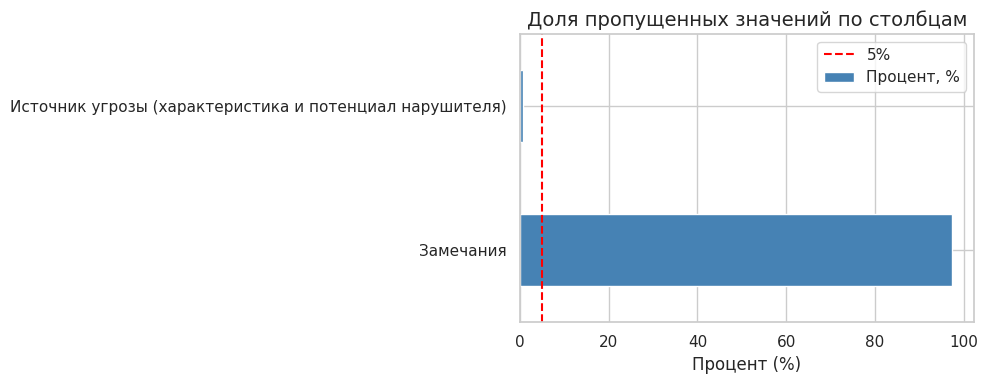

In [9]:
# Количество пропусков в каждом столбце (по убыванию)
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Пропусков': missing, 'Процент, %': missing_pct})
missing_df = missing_df[missing_df['Пропусков'] > 0]

print(f"Столбцов с пропусками: {len(missing_df)}")
display(missing_df)

# Визуализация
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['Процент, %'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Доля пропущенных значений по столбцам')
    ax.set_xlabel('Процент (%)')
    ax.axvline(5, color='red', linestyle='--', label='5%')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Приведение типов данных

Правильные типы данных критически важны для дальнейшего анализа и feature engineering.
Даты должны быть `datetime64`, числа — `float`/`int`.


In [10]:
def change_dtype_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Приводит столбцы к правильным типам данных:
    - datetime колонки: парсим с учётом российского формата (dayfirst=True)
    - числовые колонки: конвертируем через pd.to_numeric (ошибки → NaN)
    """
    df = df.copy()

    datetime_cols = [
        'Региональное время',
        'Дата инцидента',
        'Дата включения угрозы в БнД УБИ',
        'Дата последнего изменения данных'
    ]
    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
            print(f"  ✓ {col} → datetime64")

    numeric_cols = [
        'Количество хостов', 'Успех',
        'Код реализованной угрозы', 'Код предприятия', 'Идентификатор УБИ'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"  ✓ {col} → numeric")

    return df

df = change_dtype_dataframe(df)
print("\nТипы после преобразования:")
print(df.dtypes)

  ✓ Региональное время → datetime64
  ✓ Дата инцидента → datetime64
  ✓ Дата включения угрозы в БнД УБИ → datetime64
  ✓ Дата последнего изменения данных → datetime64
  ✓ Количество хостов → numeric
  ✓ Успех → numeric
  ✓ Код реализованной угрозы → numeric
  ✓ Код предприятия → numeric
  ✓ Идентификатор УБИ → numeric

Типы после преобразования:
Тип предприятия                                                    object
Код предприятия                                                     int64
Количество хостов                                                   int64
Код реализованной угрозы                                            int64
Успех                                                               int64
Регион размещения предприятия                                      object
Дата инцидента                                             datetime64[ns]
Региональное время                                         datetime64[ns]
Идентификатор УБИ                                           

## 7. Анализ статуса угроз

Угрозы из справочника бывают «Актуальные» и «Архивные».
Архивные угрозы — устаревшие, их стоит исключить из анализа для корректности.


In [11]:
if 'Статус угрозы' in df.columns:
    print("Распределение статусов угроз:")
    display(df['Статус угрозы'].value_counts(dropna=False).to_frame('count'))

    # Исключаем архивные угрозы
    before = len(df)
    df = df[df['Статус угрозы'] != 'Архивная'].copy()
    after = len(df)
    print(f"\nУдалено строк с архивными угрозами: {before - after} ({(before - after) / before * 100:.1f}%)")
    print(f"Осталось строк: {after}")

Распределение статусов угроз:


,count
Статус угрозы,
Опубликована,1948
Архивная,52



Удалено строк с архивными угрозами: 52 (2.6%)
Осталось строк: 1948


## 8. Временной анализ инцидентов

Изучаем динамику инцидентов во времени: когда происходят атаки, есть ли сезонность.


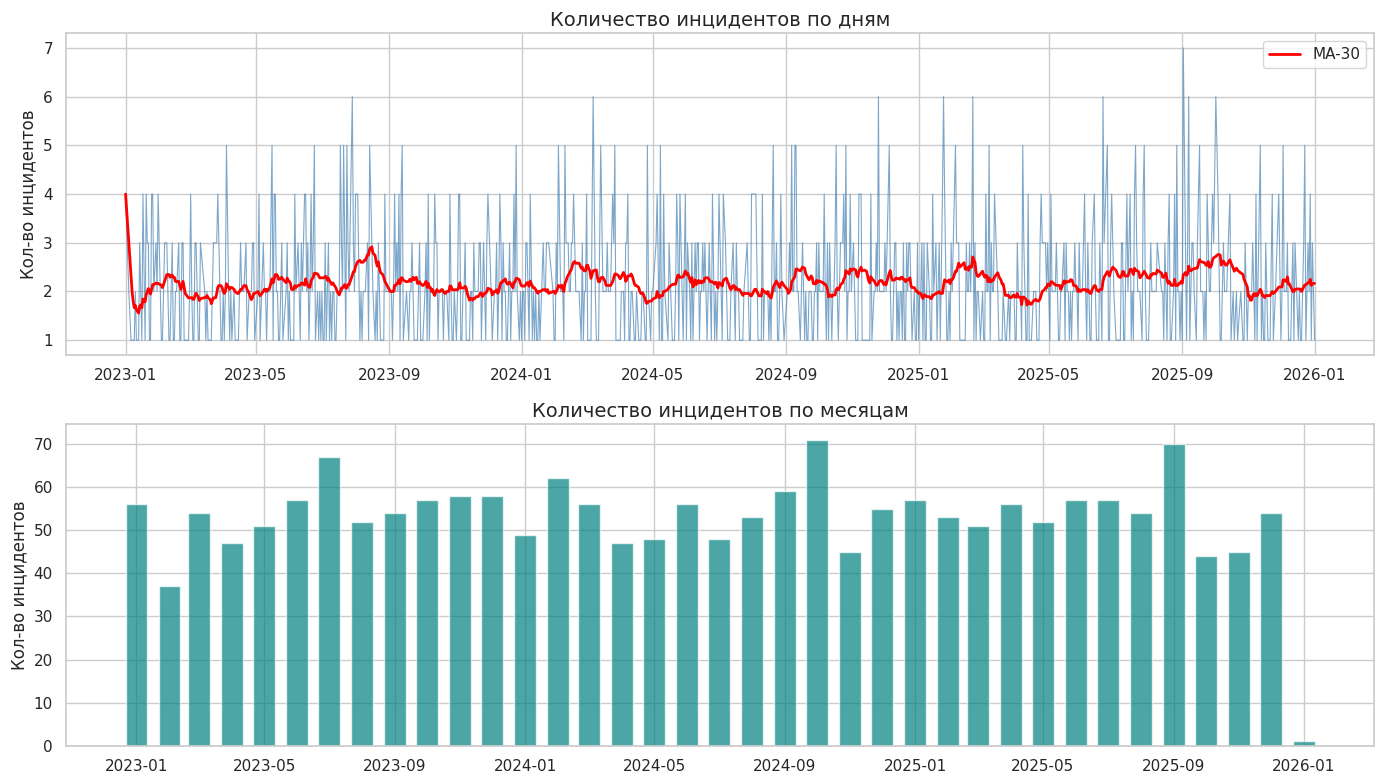

Период данных: 2023-01-01 00:00:00 → 2026-01-01 00:00:00
Всего дней: 1096


In [12]:
# Дата события (без времени суток)
df['date'] = pd.to_datetime(df['Региональное время'].dt.date)

# Инциденты по дням
daily_count = df.groupby('date').size().reset_index(name='count')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# График 1: ежедневная динамика
axes[0].plot(daily_count['date'], daily_count['count'], color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].set_title('Количество инцидентов по дням')
axes[0].set_ylabel('Кол-во инцидентов')
# Скользящее среднее 30 дней
rolling_mean = daily_count.set_index('date')['count'].rolling('30D').mean()
axes[0].plot(rolling_mean.index, rolling_mean.values, color='red', linewidth=2, label='MA-30')
axes[0].legend()

# График 2: инциденты по месяцам
df['year_month'] = df['Региональное время'].dt.to_period('M')
monthly = df.groupby('year_month').size()
monthly.index = monthly.index.to_timestamp()
axes[1].bar(monthly.index, monthly.values, width=20, color='teal', alpha=0.7)
axes[1].set_title('Количество инцидентов по месяцам')
axes[1].set_ylabel('Кол-во инцидентов')

plt.tight_layout()
plt.show()

print(f"Период данных: {df['date'].min()} → {df['date'].max()}")
print(f"Всего дней: {(df['date'].max() - df['date'].min()).days}")

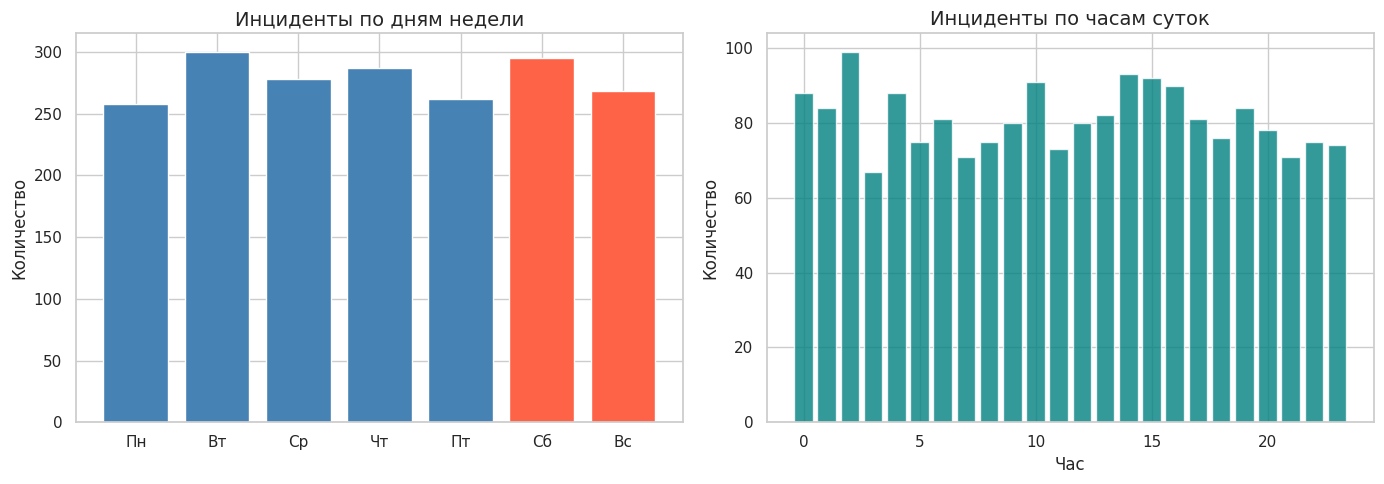

In [13]:
# Распределение по дням недели и часам суток
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По дням недели
dow_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df['day_of_week'] = df['Региональное время'].dt.dayofweek
dow_count = df['day_of_week'].value_counts().sort_index()
axes[0].bar(range(7), [dow_count.get(i, 0) for i in range(7)],
            color=['steelblue' if i < 5 else 'tomato' for i in range(7)])
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_labels)
axes[0].set_title('Инциденты по дням недели')
axes[0].set_ylabel('Количество')

# По часам суток
df['hour'] = df['Региональное время'].dt.hour
hour_count = df['hour'].value_counts().sort_index()
axes[1].bar(hour_count.index, hour_count.values, color='teal', alpha=0.8)
axes[1].set_title('Инциденты по часам суток')
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

## 9. Анализ категориальных признаков

Изучаем распределение по типу предприятия, региону и коду угрозы.


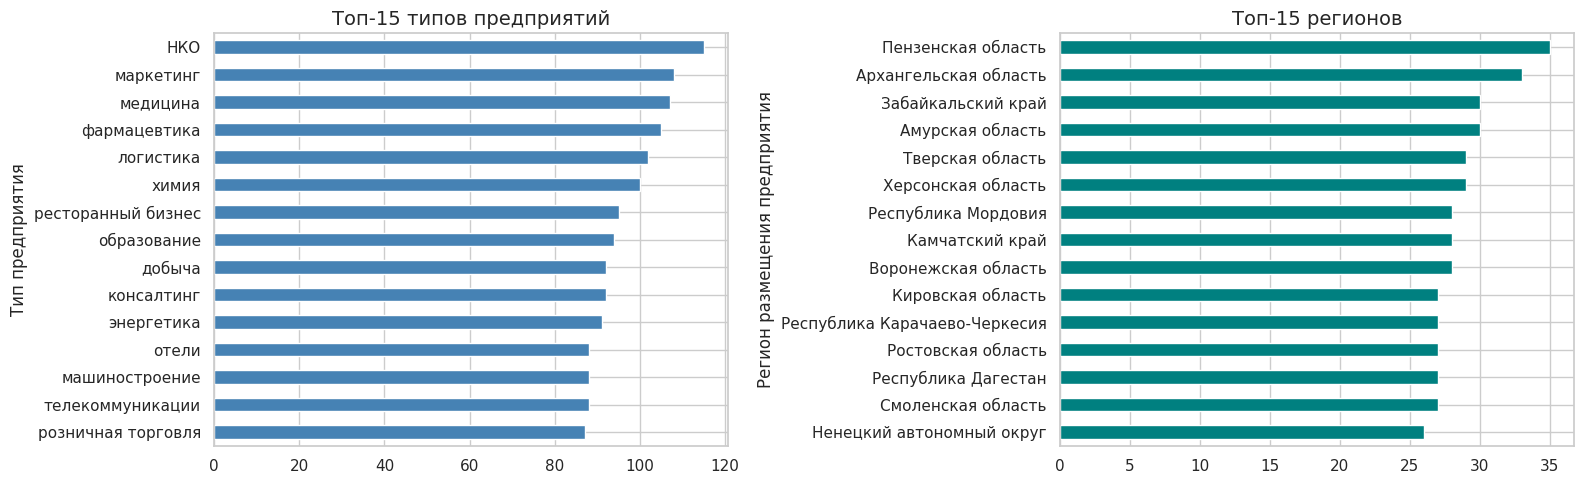

In [14]:
# Топ типов предприятий
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'Тип предприятия' in df.columns:
    top_types = df['Тип предприятия'].value_counts().head(15)
    top_types.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Топ-15 типов предприятий')
    axes[0].invert_yaxis()

if 'Регион размещения предприятия' in df.columns:
    top_regions = df['Регион размещения предприятия'].value_counts().head(15)
    top_regions.plot(kind='barh', ax=axes[1], color='teal')
    axes[1].set_title('Топ-15 регионов')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

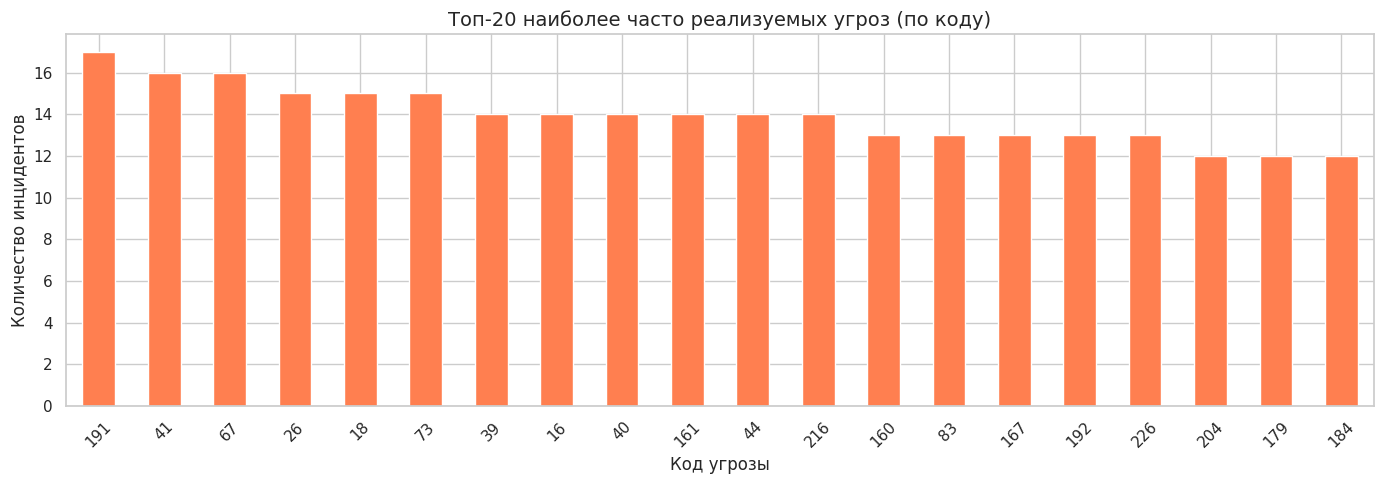


Всего уникальных кодов угроз: 222


In [15]:
# Распределение по коду угрозы
if 'Код реализованной угрозы' in df.columns:
    threat_counts = df['Код реализованной угрозы'].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(14, 5))
    threat_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title('Топ-20 наиболее часто реализуемых угроз (по коду)')
    ax.set_xlabel('Код угрозы')
    ax.set_ylabel('Количество инцидентов')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"\nВсего уникальных кодов угроз: {df['Код реализованной угрозы'].nunique()}")

## 10. Анализ целевой переменной «Успех»

Поле `Успех = 1` означает, что атака была успешной (нарушитель достиг своей цели).
Это критически важная метка — именно её предсказывает модель.


Распределение «Успех»:
Успех
1    984
0    964
Name: count, dtype: int64

Доля успешных атак: 0.505 (50.5%)


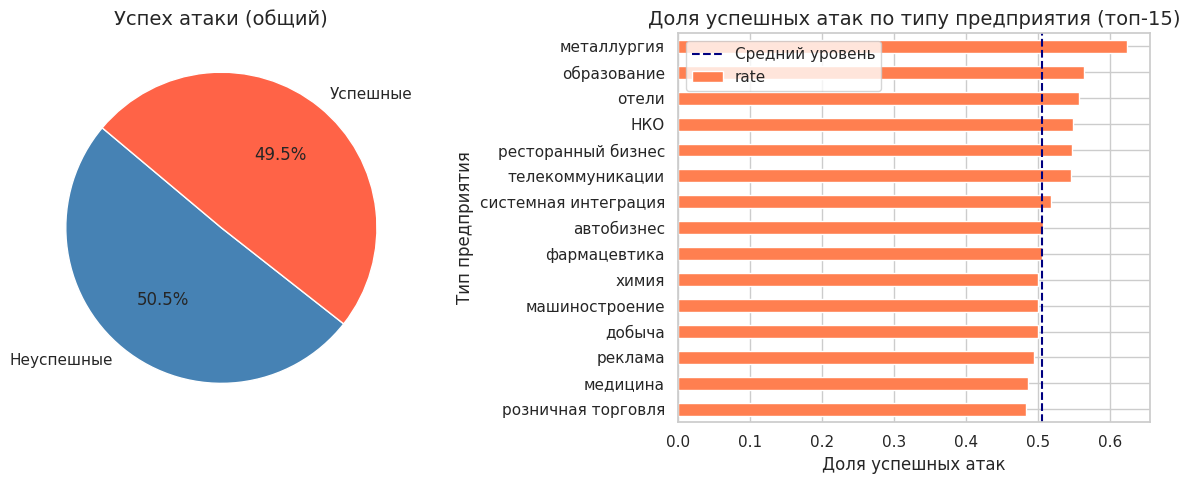

In [16]:
if 'Успех' in df.columns:
    success_counts = df['Успех'].value_counts(dropna=False)
    print("Распределение «Успех»:")
    print(success_counts)
    print(f"\nДоля успешных атак: {df['Успех'].mean():.3f} ({df['Успех'].mean()*100:.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Пирог
    axes[0].pie(success_counts.values,
                labels=['Неуспешные', 'Успешные'],
                autopct='%1.1f%%',
                colors=['steelblue', 'tomato'],
                startangle=140)
    axes[0].set_title('Успех атаки (общий)')

    # Успешность по типам предприятий
    if 'Тип предприятия' in df.columns:
        succ_by_type = (
            df.groupby('Тип предприятия')['Успех']
              .agg(['sum', 'count'])
              .assign(rate=lambda x: x['sum'] / x['count'])
              .sort_values('rate', ascending=False)
              .head(15)
        )
        succ_by_type['rate'].plot(kind='barh', ax=axes[1], color='coral')
        axes[1].set_title('Доля успешных атак по типу предприятия (топ-15)')
        axes[1].set_xlabel('Доля успешных атак')
        axes[1].invert_yaxis()
        axes[1].axvline(df['Успех'].mean(), color='navy', linestyle='--', label='Средний уровень')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

## 11. Анализ инфраструктуры (количество хостов)

Поле «Количество хостов» отражает размер IT-инфраструктуры предприятия.
Это важный признак: более крупные предприятия — более привлекательная цель.


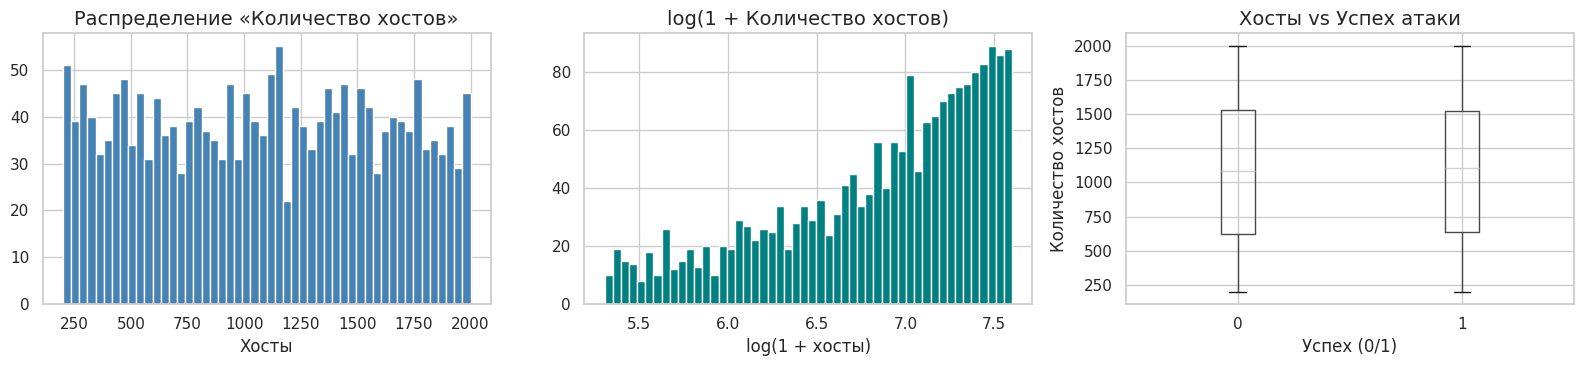

Статистика:
count    1948.0
mean     1087.9
std       521.2
min       200.0
25%       628.0
50%      1097.5
75%      1528.2
max      2000.0
Name: Количество хостов, dtype: float64


In [17]:
if 'Количество хостов' in df.columns:
    hosts = df['Количество хостов'].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Гистограмма исходного значения
    axes[0].hist(hosts, bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('Распределение «Количество хостов»')
    axes[0].set_xlabel('Хосты')

    # Логарифмическое преобразование
    axes[1].hist(np.log1p(hosts), bins=50, color='teal', edgecolor='white')
    axes[1].set_title('log(1 + Количество хостов)')
    axes[1].set_xlabel('log(1 + хосты)')

    # Boxplot с разбивкой по успеху
    if 'Успех' in df.columns:
        df.boxplot(column='Количество хостов', by='Успех', ax=axes[2])
        axes[2].set_title('Хосты vs Успех атаки')
        axes[2].set_xlabel('Успех (0/1)')
        axes[2].set_ylabel('Количество хостов')
        plt.suptitle('')  # убираем автоматический заголовок

    plt.tight_layout()
    plt.show()

    print("Статистика:")
    print(hosts.describe().round(1))

## 12. Корреляционный анализ

Смотрим на линейные зависимости между числовыми признаками.
Сильно коррелирующие признаки несут дублирующую информацию.


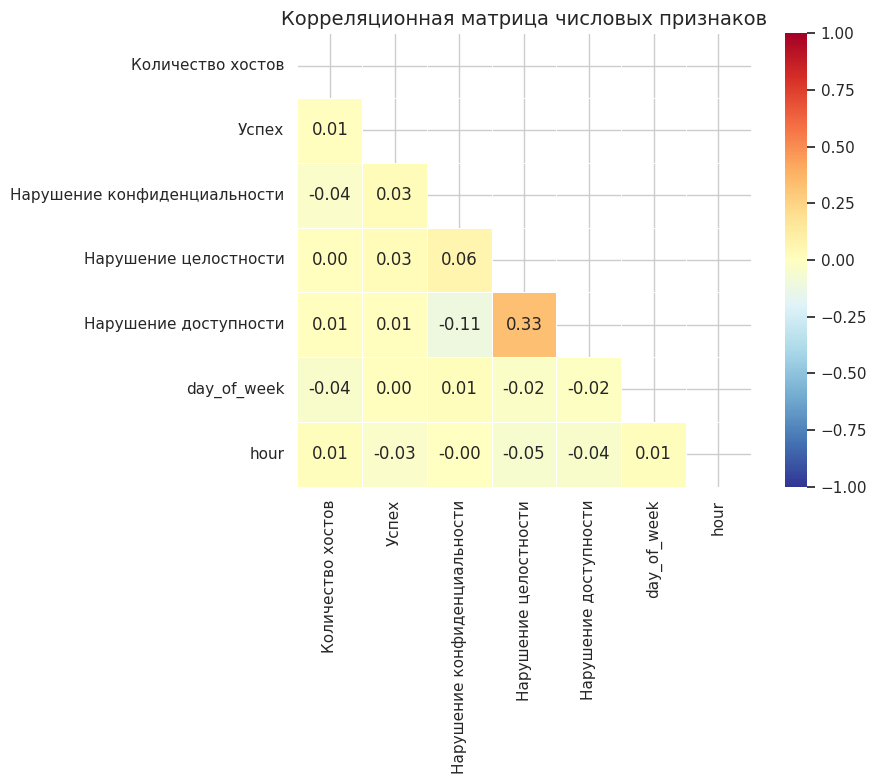

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Убираем служебные и идентификаторы
exclude_from_corr = ['Код предприятия', 'Идентификатор УБИ', 'Код реализованной угрозы']
corr_cols = [c for c in numeric_cols if c not in exclude_from_corr]

if len(corr_cols) > 1:
    corr_matrix = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdYlBu_r',
        center=0,
        vmin=-1, vmax=1,
        ax=ax,
        square=True,
        linewidths=0.5
    )
    ax.set_title('Корреляционная матрица числовых признаков')
    plt.tight_layout()
    plt.show()

## 13. Проверка дубликатов

Проверяем наличие дубликатов и решаем, как с ними поступить.


In [19]:
# Полные дубликаты
full_dupes = df.duplicated().sum()
print(f"Полных дубликатов строк: {full_dupes}")

# Дубликаты по предприятию и дате (возможная проблема)
if 'Код предприятия' in df.columns and 'date' in df.columns:
    key_dupes = df.duplicated(subset=['Код предприятия', 'date']).sum()
    print(f"Дубликатов по (Код предприятия, date): {key_dupes}")
    print("\nПримечание: несколько инцидентов на одном предприятии в один день — нормально,")
    print("на этапе агрегации мы будем считать их сумму/количество.")

Полных дубликатов строк: 0
Дубликатов по (Код предприятия, date): 0

Примечание: несколько инцидентов на одном предприятии в один день — нормально,
на этапе агрегации мы будем считать их сумму/количество.


## 14. Финальная очистка и сохранение

Сохраняем очищенный датафрейм для использования в `02_feature_engineering.ipynb`.


In [22]:
# Удаляем неинформативные столбцы
cols_to_drop = ['Дата инцидента', 'Статус угрозы', 'Замечания']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Удалены столбцы: {cols_to_drop}")

# Заполняем пропуск в «Источник угрозы» модальным значением
col_source = 'Источник угрозы (характеристика и потенциал нарушителя)'
if col_source in df.columns:
    mode_val = df[col_source].mode()[0]
    filled = df[col_source].isna().sum()
    df[col_source] = df[col_source].fillna(mode_val)
    print(f"Заполнено {filled} пропусков в '{col_source}' значением: '{mode_val}'")

# Сохранение
output_dir = Path('..')
output_dir.mkdir(parents=True, exist_ok=True)

df.to_parquet(output_dir / 'data/processed/df_clean.parquet', index=False)
print(f"\nСохранено: {output_dir / 'data/processed/df_clean.parquet'}")
print(f"Финальная форма датафрейма: {df.shape}")

Удалены столбцы: []
Заполнено 0 пропусков в 'Источник угрозы (характеристика и потенциал нарушителя)' значением: 'Внешний нарушитель с низким потенциалом; Внутренний нарушитель с низким потенциалом'

Сохранено: ../data/processed/df_clean.parquet
Финальная форма датафрейма: (1948, 21)


## 15. Итоги EDA

### Ключевые наблюдения:

1. **Данные** — журнал инцидентов ИБ с привязкой к справочнику угроз ФСТЭК.
2. **Временной охват** — данные охватывают несколько лет наблюдений.
3. **Целевая переменная** (`Успех`) — бинарная, часто несбалансирована.
4. **Размер инфраструктуры** (`Количество хостов`) — правосторонне скошенное распределение, рекомендуется логарифмирование.
5. **Архивные угрозы** удалены как устаревшие.
6. **Пропуски** — в основном в поле «Источник угрозы», заполняем модой.

### Следующий шаг:

Переходим к `02_feature_engineering.ipynb` для построения временных и агрегированных признаков.
